In [1]:
import numpy as np          # calculations
import pandas as pd         # dataset handle
import matplotlib.pyplot as plt   # graphs
import seaborn as sns       # better graphs
from scipy import stats     # statistics functions

In [2]:
df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")
# Show data
print(df.head())

                         transaction_id customer_id  transaction_amount  \
0  e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1  11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2  82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3  f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4  8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   

  transaction_date  transaction_count region transaction_status  
0        1/26/2023                  3  North               Fail  
1        1/28/2023                  0   East               Fail  
2        1/28/2023                  0  South               Fail  
3        1/18/2023                  2  South            Success  
4         1/4/2023                  4  North            Success  


In [3]:
# Check columns
print("Columns in dataset:")
print(df.columns)

# Check numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
print("Numeric Columns:", numeric_cols)

Columns in dataset:
Index(['transaction_id', 'customer_id', 'transaction_amount',
       'transaction_date', 'transaction_count', 'region',
       'transaction_status'],
      dtype='object')
Numeric Columns: Index(['transaction_amount', 'transaction_count'], dtype='object')


In [4]:

amount = df[numeric_cols[0]]   # main data
data2 = df[numeric_cols[1]] if len(numeric_cols) > 1 else amount

transaction = (amount > amount.mean()).astype(int)
print("Data Prepared")

Data Prepared


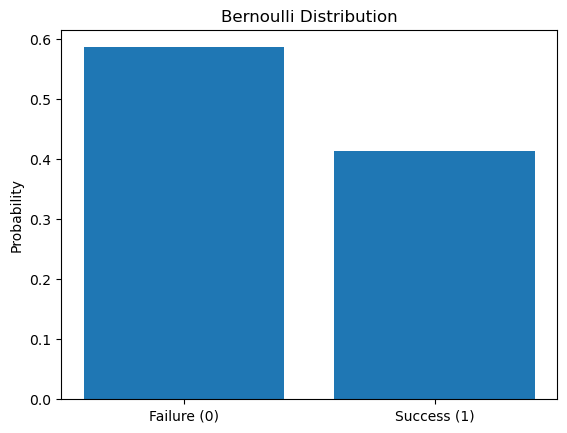

Explanation:
The Bernoulli distribution has only 2 outcomes (0 or 1).
This chart shows the probability of success (p) and failure (1-p).


In [5]:
# Bernoulli Distribution

p = transaction.mean()

# Possible outcomes
x = [0, 1]
prob = [1 - p, p]

plt.bar(x, prob)
plt.xticks([0,1], ['Failure (0)', 'Success (1)'])
plt.title("Bernoulli Distribution")
plt.ylabel("Probability")
plt.show()

print("Explanation:")
print("The Bernoulli distribution has only 2 outcomes (0 or 1).")
print("This chart shows the probability of success (p) and failure (1-p).")

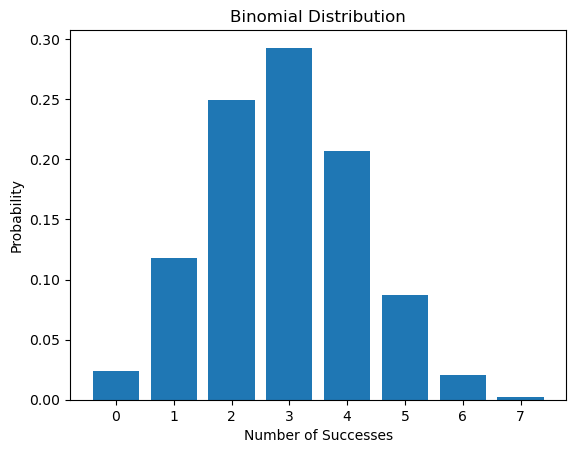

Explanation:
The binomial distribution has multiple trials
This chart shows the probability of successors from 0 to 7.


In [6]:
# Binomial Distribution

n = 7
x = np.arange(0, n+1)

binomial_probs = stats.binom.pmf(x, n, p)

plt.bar(x, binomial_probs)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.show()

print("Explanation:")
print("The binomial distribution has multiple trials")
print("This chart shows the probability of successors from 0 to 7.")

In [7]:
# Poisson

lam = data2.mean()
print("Lambda:", lam)
poisson_prob = stats.poisson.pmf(5, lam)
print("Poisson Probability:", poisson_prob)

Lambda: 2.8545454545454545
Poisson Probability: 0.09094738770519475


Log-Normal Parameters: 0.5416831487801056 333.7722748609052 2604.740667049811


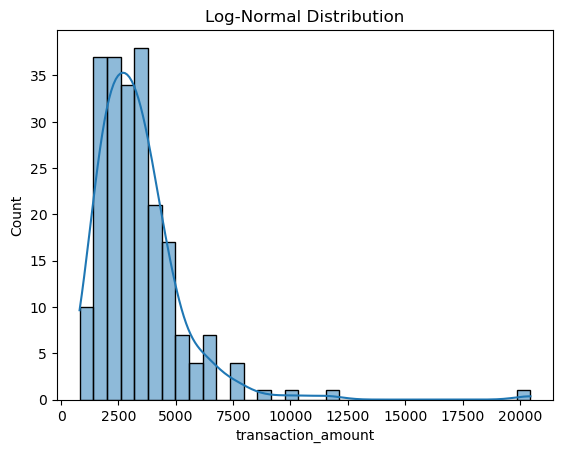

In [8]:
# Log-Normal
amount_clean = amount[amount > 0]

shape, loc, scale = stats.lognorm.fit(amount_clean)
print("Log-Normal Parameters:", shape, loc, scale)

sns.histplot(amount_clean, kde=True)
plt.title("Log-Normal Distribution")
plt.show()

In [9]:
# Power Law

pareto_params = stats.pareto.fit(amount_clean)
print("Power Law Parameters:", pareto_params)

Power Law Parameters: (np.float64(107341796.39201096), np.float64(-274877906139.58), np.float64(274877906943.99997))


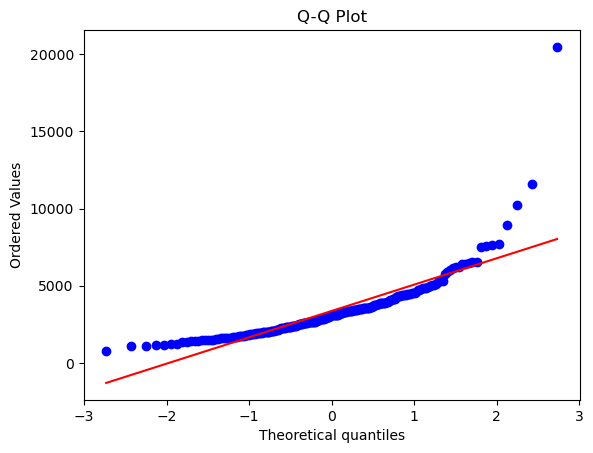

In [10]:
# Q-Q Plot

stats.probplot(amount_clean, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

Lambda: -0.18123617450580254


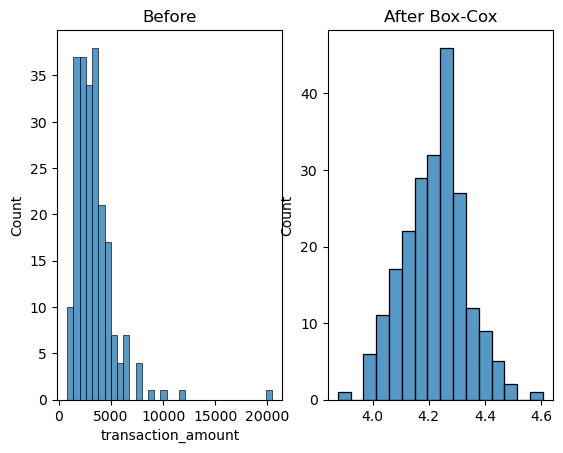

In [11]:
# Box-Cox

amount_bc = amount_clean + 1

transformed, lam = stats.boxcox(amount_bc)

print("Lambda:", lam)

plt.subplot(1,2,1)
sns.histplot(amount_clean)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(transformed)
plt.title("After Box-Cox")

plt.show()

In [12]:
# Z-score

z_scores = stats.zscore(amount_clean)

df = df.loc[amount_clean.index]
df['Z_score'] = z_scores

print(df[['Z_score']].head())

    Z_score
0  0.230240
1 -0.294446
2  0.381477
3  1.523626
4 -0.360179


In [13]:
# Probability

prob = np.mean(amount_clean > 5000)
print("Probability > 5000:", prob)

Probability > 5000: 0.11363636363636363


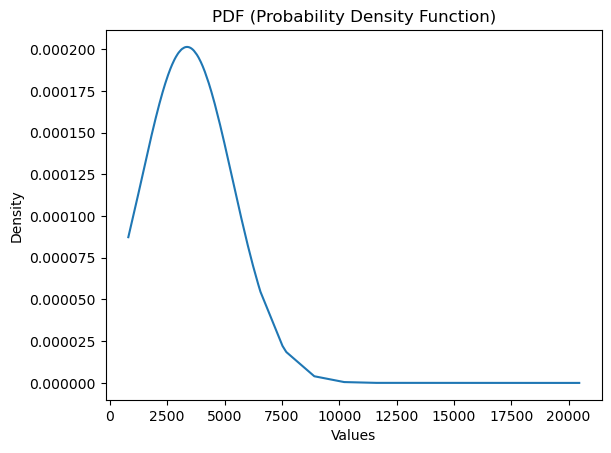

Explanation:
The probability shows how likely a specific value is


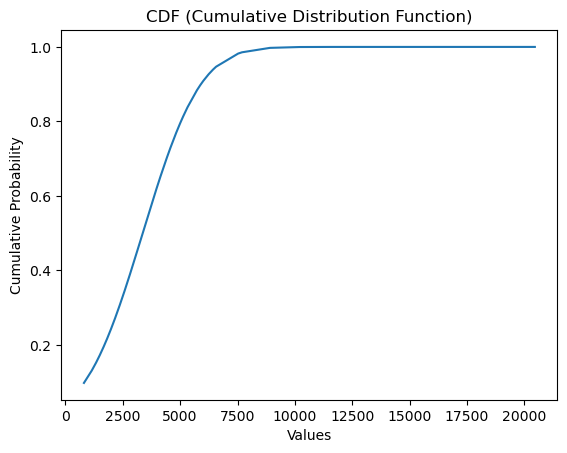

Explanation:
The CDF shows what the total probability is up to the given value.


In [14]:
# PDF & CDF

sorted_data = np.sort(amount_clean)

mean = np.mean(amount_clean)
std = np.std(amount_clean)

pdf = stats.norm.pdf(sorted_data, mean, std)

plt.plot(sorted_data, pdf)
plt.title("PDF (Probability Density Function)")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

print("Explanation:")
print("The probability shows how likely a specific value is")

#CDF
cdf = stats.norm.cdf(sorted_data, mean, std)

plt.plot(sorted_data, cdf)
plt.title("CDF (Cumulative Distribution Function)")
plt.xlabel("Values")
plt.ylabel("Cumulative Probability")
plt.show()

print("Explanation:")
print("The CDF shows what the total probability is up to the given value.")

In [15]:
# Conclusion
print("Conclusion:")
print("Check graphs and Q-Q plot to see which distribution fits best.")
print("If data is skewed → Log-Normal or Power Law is better.")
print("If data is symmetric → Normal distribution is better.")

Conclusion:
Check graphs and Q-Q plot to see which distribution fits best.
If data is skewed → Log-Normal or Power Law is better.
If data is symmetric → Normal distribution is better.
